<a class = "anchor" id="introduction-rsa"></a>
# 🔐 🔑 TP : Attaques du chiffrement RSA. 

Bienvenue dans ce TP ! Cette deuxième partie consacrée à l'algorithme RSA va nous permettre de détailler certaines attaques de l'algorithme dans sa version faiblement sécurisée (sans padding). Cette version ne devrait jamais être utilisée en pratique ! 

### 📑 Sommaire

* [Deterministic RSA](#deterministic-RSA)
* [chosen ciphertext attack](#chosen-cipher-text-attack)
* [common modulus attack](#common-modulus-attack)
* [RSA with padding](#rsa-padding)

---
*Astuce de navigation : Vous trouverez un lien "⬆️ Retour en haut" à la fin de chaque section pour revenir rapidement à ce sommaire.* </br>
*Une partie du code et des commentaires de ce notebook ont été écrits avec l'aide d'une IA.*


<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

<a class = "anchor" id="cryptography-hazmat"></a>

### Librairie cryptography et module hazmat. 

La librairie `cryptography` de Python que nous avons commencé à utiliser contient toutes les fonctions utiles en cryptographie implémentée de manière sécurisée : c'est la librairie standard pour les utilisateurs de Python. Cependant nous utilisons le module `hazmat` pour Hazardous Material parce que nous ne souhaitons pas utiliser ces fonctions dans des contextes réels mais observer leur fonctionnement en détail, y compris avec de mauvais paramétrages. Ce module, qui porte bien son nom ne devrait **jamais** être utilisé dans de vraies applications. Pour citer la documentation, 
>"You should ONLY use it if you’re 100% absolutely sure that you know what you’re doing because this module is full of land mines, dragons, and dinosaurs with laser guns.".

Mais même avec hazmat, cryptography ne vous laisse pas faire n'importe quoi. Vous ne pouvez par exemple pas générer de clé RSA pour un module de 512 bits via la fonction ```rsa.generate_private_key()``` (que se passe-t-il si vous essayez?). Vous ne pouvez pas non plus l'utiliser pour chiffrer et déchiffrer avec un RSA déterminsite : la librairie ne vous autorisera pas à utiliser RSA sans padding. 

In [74]:
%run TP-RSA-functions.ipynb

#Generate a private key

private_key = rsa.generate_private_key(
    public_exponent = 65537, 
    key_size = 1024, 
    backend=default_backend()
)

#Extract the public key from the private key
public_key = private_key.public_key()

# Extraction des nombres privés
private_numbers = private_key.private_numbers()

# Affichage des valeurs
print(f"p (premier facteur) = {private_numbers.p}")
print(f"q (second facteur)  = {private_numbers.q}")
print(f"d (exposant privé)  = {private_numbers.d}")

# Pour info, on peut vérifier que n = p * q
n = private_numbers.p * private_numbers.q
print(f"n (module) calculé  = {n}")

# Comparaison avec le module stocké dans la clé publique
print(f"n (module) officiel = {private_numbers.public_numbers.n}")


p (premier facteur) = 12060136528924409440044802340037452126849185531155933178923878279301373552617594619047143391583280536458331044311003298434246709143488230607043470866369629
q (second facteur)  = 11120408648701334354770060526970924484290556690875210295392801967999012110281606542835220761362207772196816596812301093795105224145215845688295966514812231
d (exposant privé)  = 115164162038244766549277503398999312955833776941002386897002758599625323054653754372764609860033109768722736289063337910837361076754963957035532386981995524571565820724494444905888630094868067800135038315461976999356889313780710720503540191022973145148202201813032099486867822214261481312798488409149786032713
n (module) calculé  = 13411364656076989294631909554987326924296743322107563356378040390112558944209611564809556721923680926333638907859949849250223240199886406262305535202016884337079535430220473686574019079122517377487646881189638557006710969456528225505951455750804105277152786904000718233509494030767106258677

<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

<a class = "anchor" id="deterministic-rsa"></a>

## RSA Déterministe  

Ci-dessous les fonctions de chiffrement et de déchiffrement déterministes utilisées pour mettre en évidence les faiblesses de ce type de chiffrement. 

In [149]:
# A ne surtout pas utiliser dans la vraie vie ! Ces fonctions sont à but pédagogique uniquement. 
def simple_rsa_encrypt(m, publickey):
    numbers = publickey.public_numbers()
    return gmpy2.powmod(m, numbers.e, numbers.n)

def simple_rsa_decrypt(c, privatekey):
    numbers = privatekey.private_numbers()
    return gmpy2.powmod(c, numbers.d, numbers.public_numbers.n)



Simple RSA Crypto
-----------------
	private key file: None
	public key file: None
	1. Encrypt message
	2. Decrypt message
	3. Load public key file
	4. Load private key file
	5. Create and load new public and private key files.
	6. Quit. 



>>  6




Terminating.



<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

### 1. Attaque par dictionnaire :    
**Exercice :**

* Vous trouverez joints à ce TD le fichier public_key et "secret_ciphertext.txt". Votre but est de retrouver le texte clair qui a été chiffré à l'aide de public_key et qui a donné secret_ciphertext.txt. Vous savez que votre cible n'est pas très au courant des dernières tendances en matière de cryptographie et elle a chiffré ses données sans utiliser de padding ! Par ailleurs vous savez que la donnée communiquée consistait en un unique mot et que la transaction concernait une commande de pizza.

➡️ Exécutez la fonction `main()` ci-dessous pour commencer. 

</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)

In [ ]:
main()

<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

<a class = "anchor" id="chosen_ciphertext_attack"></a>

### 2. Chosen ciphertext attack

Alice et Bob s'échangent tranquillement des informations à l'aide du couple (clé publique, clé privé) généré par Bob. La clé secrète est bien protégée et vous n'avez pas réussi à infiltrer le bureau de Bob pour la récupérer. Vous avez néanmoins repéré une faille de sécurité dans la gestion de Bob : tout d'abord lui et Alice n'utilisent pas de padding. Ensuite, lorsque Bob déchiffre un message d'Alice qui n'a aucun sens (fruit d'une erreur dans la transmission des données) il le supprime. Une copie apparaît alors temporairement dans son dossier corbeille auquel un de vos agents infiltré peut avoir accès car il n'est protégé par aucun mot de passe. Voici votre mode d'action pour exploiter cette faille : 

  1. Vous interceptez un message chiffré par Alice.
  2. Vous chiffrez vous même un message et vous multipliez votre message par celui d'Alice.
  3. Vous envoyez le message modifié à Bob.
  4. Vous récupérez le message déchiffré par Bob (k_priv_bob).

Comment pouvez-vous retrouver le message d'Alice? 

</div>

<br>

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
    
**Exercice :**

En pratique vous devez jouer à la fois les rôles d'Alice, d'Eve et de Bob dans cette simulation. Montrer ci-dessous comment, uniquement à l'aide de la clé publique, Eve peut déchiffrer le message d'Alice. 

</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)


In [6]:
%run TP-RSA-functions.ipynb
# Génération de la clé privée et de la clé publique de Bob. 
private_key = rsa.generate_private_key(
    public_exponent = 65537,
    key_size = 2048, 
    backend = default_backend()
)

public_key = private_key.public_key()

# Le message en clair qu'Alice veut transmettre à Bob

message_a = b''
message_a_int = bytes_to_int(message_a)

# Alice chiffre le message avec la clé publique de Bob
encrypted_message_a = simple_rsa_encrypt(message_a_int,public_key)

# Eve chiffre un message de son choix avec la clé publique de Bob

message_e_int = ...
encrypted_message_e = simple_rsa_encrypt(message_e_int, public_key) 

# Eve intercepte et modifie le message d'Alice 
tampered_encrypted_message_a = ... 

# Bob déchiffre le message transmis par Eve
tampered_plain_message_a = simple_rsa_decrypt(tampered_encrypted_message_a)

# Alice récupère le message modifié et s'en sert pour déchiffrer le message d'Alice
tampered_plain_message_a_int = bytes_to_int(tampered_plain_message_a)
plain_message_a = ''

print("Verification plain_message_a == message_a : " plain_message_a == message_a)




TypeError: powmod() argument types not supported

<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

<a class = "anchor" id="common-modulus-attack"></a>

### 2. Common modulus attack

Bob vient d'être rejoint par sa collègue Maddie, Alice devra maintenant envoyer les informations à Bob et Maddie. Par mesure de sécurité, l'agence d'espionnage qui a recruté Bob et Maddie leur demande de ne pas partager leurs clés privées. Maddie doit donc générer un nouveau couple (clé privée, clé publique) pour communiquer avec Alice. Hélas, au moment de générer p et q, les grands nombres premiers utilisés pour calculer le module n, l'ordinateur de Maddie plante. Cette opération étant très lente, elle n'a pas le temps de recommencer le calcul avant le début de sa mission, l'agence d'espionnage lui demande donc d'utiliser le module n de Bob mais avec des exposants publics et privés différents.

Quand Madie envoie sa clé publique à Alice, vous constatez que le module n est le même que celui de Bob ! Vous n'en revenez pas, vous allez pouvoir lancer l'attaque des modules communs. 

Tous les mercredi matins, Alice envoie le menu de la cantine (en version chiffrée, information hautement confidentiel) à Bob et Maddie. Vous interceptez les deux messages et aller les déchiffrer sans jamais utiliser les clés secrètes. 
</div>

<br>

La théorie : 

On note $e_1$ l'exposant public de Bob et $e_2$ l'exposant public de Maddie. Ceux-ci ont été générés aléatoirement et par chance, **$e_1$ et $e_2$ sont premiers entre eux** ce qui était un critère essentiel de réussite de votre attaque! Eve calcule les coefficients de Bézout $(u,v)$ tels que : 
$$ ue_1 + ve_2 = 1$$

Alice encode le message $\overline{x}^{e_1}$ puis $\overline{x}^{e_2}$. Comme Bob et Maddie utilisent un module commun, les deux exponentiations ont lieu dans $\mathbb{Z}_n$. 

Eve récupère les deux messages chiffrés et calcule : 
$$ \left(\overline{x}^{e_1}\right)^u \times \left( \overline{x}^{e_2} \right)^v = \overline{x}^{ue_1 + ve_2} = \overline{x} \qquad \text{ dans } \mathbb{Z}_n$$

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
    
**Exercice :**



</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)

In [3]:
%run TP-RSA-functions.ipynb

private_key = rsa.generate_private_key(
    public_exponent = 65537,
    key_size = 2048, 
    backend = default_backend()
)

public_key = private_key.public_key()
n = public_key.public_numbers().n
a = 5
b = 10

encrypted_a = simple_rsa_encrypt(a,public_key)
encrypted_b = simple_rsa_encrypt(b,public_key)

encrypted_product = (encrypted_a*encrypted_b) % n # produit modulo n

decrproduct = simple_rsa_decrypt(encrypted_product,private_key)
print("{}x{} = {}".format(a,b,product))


5x10 = 50


<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

<a class = "anchor" id="rsa-padding"></a>

# 🛡️ Le rôle crucial du Padding en RSA : OAEP 

Si la formule mathématique de RSA ($c = m^e \bmod n$) est élégante, elle est malheureusement peu sécurisée si on l'utilise telle quelle dans le monde réel. C'est ce qu'on appelle le **Textbook RSA**.

### 1. Pourquoi avons-nous besoin de Padding ?

Le Textbook RSA souffre de plusieurs défauts majeurs :
* **Il est déterministe :** Si vous chiffrez le mot "OUI" aujourd'hui et demain avec la même clé, le chiffré sera exactement le même. Un attaquant observant le réseau peut en déduire des informations (analyse de trafic).
* **Les petits messages :** Si le message $m$ et l'exposant $e$ sont très petits (ex: $e=3$), il se peut que $m^e$ soit inférieur à $n$. Le modulo n'a alors aucun effet, et l'attaquant n'a qu'à faire une simple racine cubique classique pour retrouver le message !
* **La malléabilité :** (La propriété multiplicative vue précédemment). Un attaquant peut modifier un cryptogramme en vol pour altérer le sens du message déchiffré à l'arrivée sans que cela ne soit détectable. 

**La solution : Le Padding (Remplissage).** Avant de faire l'exponentiation modulaire, on va augmenter le message avec une chaîne de bits aléatoires et des balises.

---

### 2. Le Padding de Chiffrement : OAEP



**OAEP** (*Optimal Asymmetric Encryption Padding*) est le standard absolu pour chiffrer des données avec RSA. 

On commence par augmenter le message pour obtenir une chaîne de bits de la même taille que le module n (2048 bits dans notre exemple). 
* Les 8 premiers bits sont toujours 0 ce qui majore la chaîne à $2^{2018}$.
* **Seed** : Une chaîne aléatoire est ajoutée pour casser le déterminisme.
* **label** : La signature du label (son hash de taille fixe) est accolée au bloc.
* **padding** : Pour que le bloc final fasse 2048 bits, on ajoute autant de bits nuls que nécessaire.
* **Balise** : C'est l'octet $01$ en hexadécimal soit $00000001$ en bits sert de balise pour signifier la fin du padding et le début du message.
* **message** : A la fin du bloc se trouve le vrai message que souhaite chiffrer l'envoyeur. Sa taille est limité par l'ajout de tous les bits précédents, le message est donc codé sur $1520$ bits soit 190 octets. Votre message s'écrit donc sur 190 caractères ascii au maximum. 

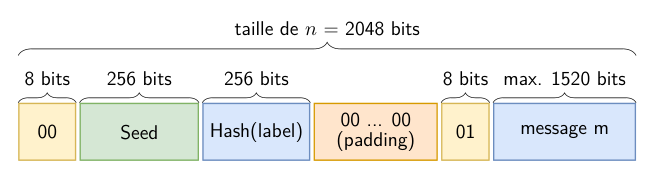

A ce stade on a bien cassé le déterminisme de RSA, le seul élément non-déterministe du message augmenté est la chaîne "Seed" générée aléatoirement pour chaque nouveau chiffrement et cela suffit. Cependant OAEP ne s'arrête pas ici !

En effet, si on chiffre directement ce message augmenté, un attaquant peut encore le modifier de manière prévisible. Par exemple, s'il le multiplie avec la valeur chiffrée de $2^4$ il translate effectivement les bits de message de $4$ rangs vers la gauche. 
Par ailleurs, ce genre de modification est sensible aux attaques par oracle de padding, c'est le cas du protocole de padding PKCS1v1.5 qui a un fonctionnement similaire à ce que nous venons de décrire.  

Pour compléter le protocole et corriger tous les défauts du textbook RSA et des oracles de padding, la deuxième étape d'OAEP consiste à appliquer des **masques**. Le générateur de masque est **MGF1**, pour générer des bits d'apparence aléatoire cette fonction utilise une fonction de Hash, d'où l'initialisation `MGF1(algorithm = hashes.SHA256())` dans les paramètres de la fonction `public_key.encrypt()`. 

On considère deux blocs : 
* **DB (Data Block)** : Contient le message, le padding et le hash du label ($190$ octets pour RSA-2048).
* **Seed** : Une valeur aléatoire de $32$ octets.

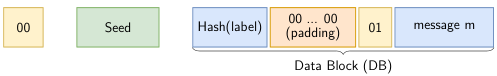

**Étape A : Masquage du Data Block**
On utilise la `Seed` pour brouiller le `DB`. Comme le `DB` est long, la MGF1 "étire" la Seed :
1. On calcule le masque : $Mask_{DB} = MGF(\text{Seed}, \text{taille\_DB})$
2. On applique le XOR : $\mathbf{MaskedDB} = DB \oplus Mask_{DB}$

**Étape B : Masquage de la Seed (Le "Nœud" de sécurité)**
Pour protéger la `Seed` et lier l'ensemble, on utilise le `MaskedDB` pour brouiller la `Seed` :
1. On calcule le masque : $Mask_{Seed} = MGF(\text{MaskedDB}, 32)$
2. On applique le XOR : $\mathbf{MaskedSeed} = \text{Seed} \oplus Mask_{Seed}$

> **Note :** Comme la `Seed` fait 32 octets et que SHA-256 produit 32 octets, $Mask_{Seed}$ est simplement $\text{Hash}(\text{MaskedDB} \parallel 0)$.

#### 3. Résultat Final
Le bloc final à chiffrer par RSA est la concaténation :
$$\text{Encoded Message (EM)} = [0x00] \parallel \text{MaskedSeed} \parallel \text{MaskedDB}$$

---
**Pourquoi cette structure ?**
Si un seul bit du `MaskedDB` est modifié par un attaquant, lors du déchiffrement :
1. La fonction $MGF(\text{MaskedDB})$ produira un masque de graine totalement différent.
2. La `Seed` retrouvée sera fausse.
3. Cette `Seed` fausse, passée dans la seconde MGF, produira un message final totalement chaotique, rendant toute manipulation impossible à l'insu du destinataire.


[⬆️ Retour au sommaire](#introduction-tp)


<a id="oaep-dechiffrement"></a>
### 🔓 Le Déchiffrement OAEP : Comment retirer le masque ?


Imaginons que le destinataire vient d'utiliser sa clé privée pour faire le calcul mathématique ($x^d \pmod n$) et a reconverti le résultat en octets. Il a maintenant sous les yeux le bloc complet **Encoded Message (EM)**.

Comment fait-il pour retrouver le message sans connaître la `Seed` de départ ? Il va utiliser la propriété fondamentale du XOR : **appliquer deux fois le même masque annule l'effet** ($A \oplus B \oplus B = A$).

Voici les 4 étapes exactes du démasquage :

#### Étape 1 : Le Découpage
Le destinataire sait quelle fonction de hachage a été utilisée (ex: SHA-256). Il sait donc que la `Seed` fait exactement 32 octets. En lisant le bloc **EM** de gauche à droite, il peut le découper à l'aide des balises :
1. Il vérifie que le 1er octet est bien `00` (sinon $\rightarrow$ Erreur).
2. Il coupe les 32 octets suivants : c'est le **`maskedSeed`**.
3. Tout le reste du bloc constitue le **`maskedDB`**.

#### Étape 2 : Retrouver la Seed 
C'est ici qu'intervient l'astuce du réseau de Feistel. Le destinataire possède le `maskedDB`. 
* Il le fait passer dans la fonction **MGF** : `MGF(maskedDB)`.
* Puisque la fonction MGF est déterministe, elle génère **exactement le même masque** que l'expéditeur avait utilisé pour cacher la graine ! Appelons-le `seedMask`.
* Il fait un XOR : **`Seed`** = `maskedSeed` $\oplus$ `seedMask`.
* *Tadam ! Le destinataire a récupéré la graine aléatoire originale.*

#### Étape 3 : Retrouver le Data Block (DB)
Maintenant qu'il possède la véritable `Seed`, le reste suit naturellement :
* Il fait passer cette `Seed` dans la fonction **MGF** : `MGF(Seed)`.
* La fonction donne le masque principal : `DBMask`.
* Il fait un dernier XOR : **`DB`** = `maskedDB` $\oplus$ `DBMask`.
* *A ce stade, le bloc de données est en clair !*

#### Étape 4 : Vérification 
Le destinataire a sous les yeux le bloc **DB** original (`Hash(L) + Padding + 01 + Message m`). les vérifications de sécurité sont :
1. Le `Hash(L)` correspond-il au contexte attendu ?
2. Y a-t-il bien une suite de zéros (`Padding`) qui se termine par l'octet `01` ?
* Si tout est parfait, le programme isole le **Message m** situé tout à la fin et le livre à l'utilisateur. Si un seul bit de l'Encoded Message est modifié par un pirate, la corruption est évidente car la structure du bloc n'est pas respectée. 

In [9]:
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.primitives import hashes

message = b'je pense donc je suis'
private_key = rsa.generate_private_key(
    public_exponent = 65537,
    key_size = 2048,
    backend=default_backend()
)
public_key = private_key.public_key()

ciphertext1 = public_key.encrypt(message,padding.OAEP(
    mgf = padding.MGF1(algorithm = hashes.SHA256()),
    algorithm = hashes.SHA256(),
    label = None # rarely used. Just leave it 'None'
    )
)

ciphertext2 = public_key.encrypt(message,padding.OAEP(
    mgf = padding.MGF1(algorithm = hashes.SHA256()),
    algorithm = hashes.SHA256(),
    label = None # rarely used. Just leave it 'None'
    )
)

recovered1 = private_key.decrypt(
    ciphertext1,
    padding.OAEP(
        mgf = padding.MGF1(algorithm = hashes.SHA256()),
        algorithm = hashes.SHA256(),
        label = None # rarely used. Just leave it 'None'
    )
)

recovered2 = private_key.decrypt(
    ciphertext2,
    padding.OAEP(
        mgf = padding.MGF1(algorithm = hashes.SHA256()),
        algorithm = hashes.SHA256(),
        label = None # rarely used. Just leave it 'None'
    )
)


print("Plaintext : {}".format(message))
print("\nCiphertext1 (OAEP) : {}".format(ciphertext1.hex()))
print("\nCiphertext2 (OAEP) : {}".format(ciphertext2.hex()))
print("\nRecovered 1 : {}".format(recovered1))
print("Recovered 2 : {}".format(recovered2))





Plaintext : b'je pense donc je suis'

Ciphertext1 (OAEP) : 4025c5c78bb970dee40df32efd29afeb1b7d0f2f40c23bab9773ad9b0cb2dac399967d0b3a946283c9ec5fd14fb8708c0044479bd630af32b3fa703fe41cfb704c60e8f0e61c0685ad1792a8eb998325dd6986ee3e1a7769c48bb48accd4f87a28c708804ead9d7ab5d06db4b1bf6a89819fcc7df962aca69cbd6e926d4bd03841b08aeaa2e40d945f07c59a0a90527bf689f25d519d84b98e2c8a87197fad0a1a8e24c395b6cbbf6f4a947cc6d8ec6f8a0553e1b86f15f101e90f6c650e58d05bd8c8f0ddece0ac6a3c4c19487acfcd5e0e3d31c3792a98c45caafb6326e0ba8cd2bfabccfc4cba66b593c6bca123c3e9adaffc63a1fb194c1e7b7eb5d4adaa

Ciphertext2 (OAEP) : 6ac9ffac36bca3d91bb5bbb298fb1e29ec070e0f3c5a79441b5d299d3f9e5346020f5eca84e1d7a6861b7710733383303d201012b2f88dc1fde238ca7f14f24325206612ab9fe001ca10ed577d7601fbad5893149c72cf3b427ba6d51a2d539d15f86f082ab5bff2d6b33edd0e7d35f03f5b07b8c15c9c59494795e6de90a7eb138e4ea3536eab98f8567ad5d15c16e03d2f231b768b724dd58836bafb713cdc717353ca7320b68856b303f7b231d329215f87ffb9ed0b7f22cef24fbc191fcae0c2f0046c820b75c268d5

### 3. Le Padding de Signature : PSS

Le standard de padding pour les signatures RSA s'appelle **PSS** (*Probabilistic Signature Scheme*).

Contrairement au chiffrement (où l'on cache un message pour qu'il soit lu), une signature sert à **prouver son identité**. 

**Pourquoi ne pas signer le message directement ?**
Si on signe juste le haché (Hash) du message, la signature sera déterministe. Pour plus de sécurité, PSS rend la signature **probabiliste** (aléatoire).

**Comment ça marche ?**
1. Au lieu de signer juste le "Hash" de votre document, PSS génère un **Sel aléatoire** (Salt).
2. Il combine ce Sel et le Hash du document pour créer un nouveau Hash unique.
3. Il utilise ensuite **MGF1** pour formater tout cela dans un EM (encoded message) de la bonne taille (avec des zéros et des marqueurs spécifiques).
4. Enfin, on applique la formule mathématique de signature RSA ($y = EM^d \bmod n$).

**Résultat :** Même si vous signez le même document 100 fois, vous obtiendrez 100 signatures complètement différentes (grâce au Sel). Pourtant, n'importe qui avec votre clé publique pourra vérifier que toutes ces signatures valident bien ce document unique !

---

<a id="exercice-final"></a>

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
    
**Exercice :**

Pour cette dernière étape, nous allons utiliser les vrais outils de l'industrie fournis par la bibliothèque `cryptography`. 

**Rappel important :** Dans le monde réel, les algorithmes de cryptographie ne manipulent pas de texte (`str`), mais des séquences d'octets (`bytes`). En Python, on préfixe une chaîne par `b` pour la déclarer en octets (ex: `b"Mon secret"`).

**Dans l'ordre :**
1. Générer une véritable paire de clés RSA.
2. Signer un message officiel (en octets) en utilisant la clé privée et le padding **PSS**.
3. Vérifier que la clé publique valide bien cette signature.
4. Tenter de falsifier le document et observer comment la fonction de vérification réagit !

</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)



In [11]:
from cryptography.exceptions import InvalidSignature

print("--- 1. Génération des clés ---")
private_key = rsa.generate_private_key(public_exponent=65537, key_size=2048, backend=default_backend())
public_key = private_key.public_key()
print("Clés générées avec succès !\n")

# Le message DOIT être en bytes (octets) ! Notez le 'b' devant les guillemets.
message = b"Ordre de virement : 100 euros."

print("--- 2. Signature du message ---")
# TODO 1 : Signez le message avec private_key.sign()
# Utilisez padding.PSS avec mgf=padding.MGF1(hashes.SHA256()) et salt_length=padding.PSS.MAX_LENGTH
# L'algorithme principal de hachage doit être hashes.SHA256()

signature = ... 

print(f"Signature générée (en hexadécimal, tronquée) : {signature.hex()[:50]}...\n")

print("--- 3. Vérification de la signature ---")
# TODO 2 : Vérifiez la signature avec public_key.verify()
# Attention : Les paramètres de padding et de hachage doivent être EXACTEMENT les mêmes qu'à la signature !

try:
    # Remplacez le 'pass' par l'appel à votre fonction de vérification
    pass
    print("✅ Succès : La signature est valide, le document est authentique !")
except InvalidSignature:
    print("❌ Erreur : La signature est invalide !")

print("\n--- 4. Tentative de falsification ---")
message_falsifie = b"Ordre de virement : 1000000 euros."

# TODO 3 : Essayez de vérifier la signature originale, mais en utilisant le message_falsifie.
try:
    # Remplacez le 'pass' par l'appel à votre fonction de vérification sur le faux message
    pass
    print("✅ Succès : La signature est valide, le document est authentique !")
except InvalidSignature:
    print("❌ Rejet de sécurité : Le document a été altéré, la signature ne correspond plus !")

--- 1. Génération des clés ---
Clés générées avec succès !

--- 2. Signature du message ---


AttributeError: 'ellipsis' object has no attribute 'hex'